# Olist E-Commerce — Exploratory Data Analysis

## What is this notebook?
This notebook explores 100,000+ real Brazilian e-commerce orders from the Olist dataset.

Before building ML models or SQL queries, we look at the data visually to:
- Understand the shape and quality of the data
- Find patterns and trends
- Identify problems like missing values or outliers
- Generate business insights

## Dataset columns we will analyse
| Column | What it means |
|---|---|
| revenue | Total payment value for the order |
| delivery_days | How many days delivery took |
| is_late | 1 = delivered after estimated date, 0 = on time |
| review_score | Customer rating from 1 to 5 |
| category | Product category in English |
| customer_state | Brazilian state the customer is in |
| day_of_week | Day the order was placed |

In [1]:
# Loading all the tools we need for this analysis
# pandas     → work with tables (like Excel but in Python)
# numpy      → math and numbers
# matplotlib → draw basic charts
# seaborn    → draw nicer, more detailed charts

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# This line makes charts appear inside the notebook instead of a separate window
%matplotlib inline

# Set a clean modern chart style and a comfortable default size
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

print("All libraries loaded!")

All libraries loaded!


## Step 1 — Load the Data

We load the cleaned CSV file created by our ETL pipeline.
We also convert the purchase date column back into a proper date object
because CSV files save everything as plain text.

In [2]:
# Load the file we created in etl_transform.py
df = pd.read_csv("transformed_data.csv")

# Convert the date column from plain text back to a real date object
# This lets us do date math like calculating delivery days
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

print(f"Dataset loaded successfully")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"\nDate range: {df['order_purchase_timestamp'].min().date()}  to  "
      f"{df['order_purchase_timestamp'].max().date()}")

Dataset loaded successfully
Rows    : 110,123
Columns : 15

Date range: 2016-09-15  to  2018-08-29


### What does the data look like?

Let us take a quick first look at the top rows — like scrolling to the top of an Excel file.
This tells us the column names, sample values, and confirms everything loaded correctly.

In [3]:
# .head() shows the first 5 rows of the dataset
df.head()

,order_id,customer_id,customer_state,order_purchase_timestamp,year,month,month_name,quarter,day_of_week,category,price,revenue,delivery_days,is_late,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,SP,2017-10-02 10:56:33,2017,10,Oct,4,Monday,housewares,29.99,38.71,8.0,0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,BA,2018-07-24 20:41:37,2018,7,Jul,3,Tuesday,perfumery,118.70,141.46,13.0,0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,GO,2018-08-08 08:38:49,2018,8,Aug,3,Wednesday,auto,159.90,179.12,9.0,0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,RN,2017-11-18 19:28:06,2017,11,Nov,4,Saturday,pet_shop,45.00,72.20,13.0,0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,SP,2018-02-13 21:18:39,2018,2,Feb,1,Tuesday,stationery,19.90,28.62,2.0,0,5.0


### Column Types and Data Quality

Next we check what type of data each column holds and whether any values are missing.
Missing values are like empty cells in Excel — they can break calculations if not handled.

In [4]:
# .dtypes shows each column name and its data type
# object  = text
# int64   = whole numbers like 1, 2, 3
# float64 = decimal numbers like 1.5, 100.75

print("Column names and their data types:")
print(df.dtypes)

Column names and their data types:
order_id                            object
customer_id                         object
customer_state                      object
order_purchase_timestamp    datetime64[ns]
year                                 int64
month                                int64
month_name                          object
quarter                              int64
day_of_week                         object
category                            object
price                              float64
revenue                            float64
delivery_days                      float64
is_late                              int64
review_score                       float64
dtype: object


In [5]:
# Check how many values are missing in each column
# and what percentage of the total that represents

missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %"    : missing_pct
})

# Only show columns that actually have missing values
has_missing = missing_table[missing_table["Missing Count"] > 0]

if len(has_missing) > 0:
    print("Columns with missing values:")
    print(has_missing)
else:
    print("No missing values found")

Columns with missing values:
              Missing Count  Missing %
review_score            825       0.75


## Step 2 — Basic Statistics

Before drawing charts, we look at the raw numbers.
The .describe() function gives us a full summary for every numeric column:

- **count** → how many rows have data
- **mean**  → the average
- **std**   → how spread out the values are (standard deviation)
- **min**   → the smallest value
- **50%**   → the middle value (also called the median)
- **max**   → the largest value

We focus on revenue, delivery_days, and review_score — our three most important columns.

In [6]:
# Get full statistics for our three key columns
df[["revenue", "delivery_days", "review_score"]].describe().round(2)

,revenue,delivery_days,review_score
count,110123.00,110123.00,109298.00
mean,179.39,11.94,4.08
std,271.26,8.90,1.35
min,9.59,1.00,1.00
25%,65.56,6.00,4.00
50%,114.33,10.00,5.00
75%,194.91,15.00,5.00
max,13664.08,118.00,5.00


**What to notice here:**
Compare the mean (average) and the 50% (median) for revenue.
If the mean is much higher than the median, it means a few very large orders
are pulling the average up — and the median better represents a typical customer.

## Step 3 — Revenue Distribution

A histogram shows how order values are spread across different price ranges.
X axis = revenue amount, Y axis = how many orders had that value.

We draw two charts:
- Left: all orders (shows the full picture including big outliers)
- Right: bottom 99% only (removes extreme outliers so we can see where most orders fall)

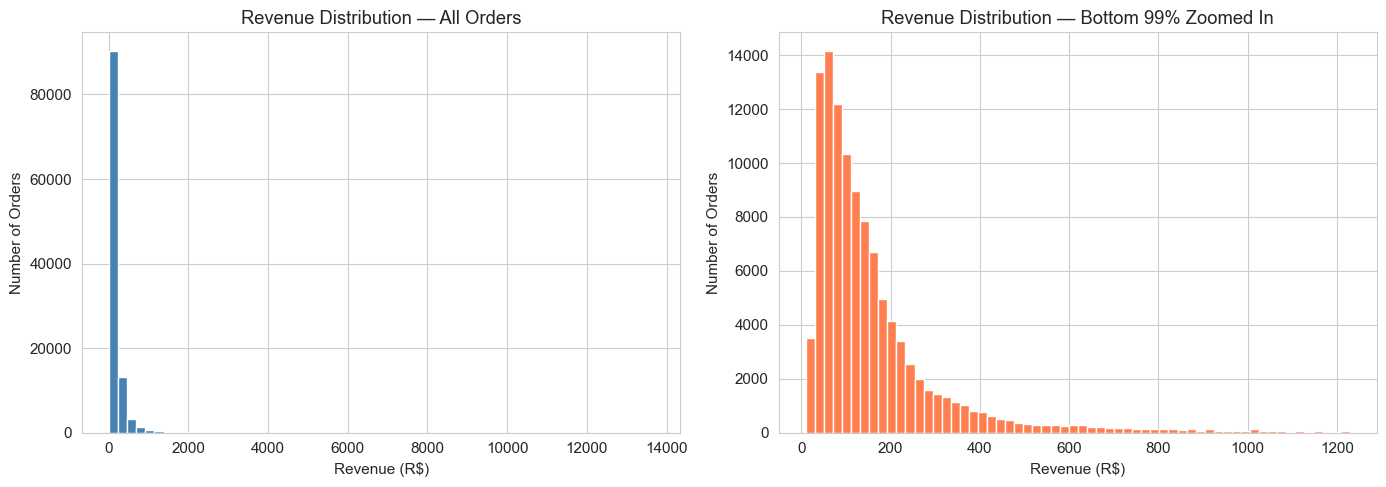

Average order value : R$    179.39
Median order value  : R$    114.33
Smallest order      : R$      9.59
Largest order       : R$ 13,664.08


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart — show every order
axes[0].hist(df["revenue"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Revenue Distribution — All Orders")
axes[0].set_xlabel("Revenue (R$)")
axes[0].set_ylabel("Number of Orders")

# Right chart — remove top 1% so we can zoom in on where most orders sit
top_1_pct = df["revenue"].quantile(0.99)
df_zoomed = df[df["revenue"] < top_1_pct]

axes[1].hist(df_zoomed["revenue"], bins=60, color="coral", edgecolor="white")
axes[1].set_title("Revenue Distribution — Bottom 99% Zoomed In")
axes[1].set_xlabel("Revenue (R$)")
axes[1].set_ylabel("Number of Orders")

plt.tight_layout()
plt.savefig("eda_revenue_distribution.png", dpi=150)
plt.show()

print(f"Average order value : R${df['revenue'].mean():>10,.2f}")
print(f"Median order value  : R${df['revenue'].median():>10,.2f}")
print(f"Smallest order      : R${df['revenue'].min():>10,.2f}")
print(f"Largest order       : R${df['revenue'].max():>10,.2f}")

**Insight from this chart:**
The average is much higher than the median.
This tells us most customers place small orders,
but a few very large orders pull the average up.
When reporting revenue to a business, always mention both the mean and median.

## Step 4 — Monthly Revenue Trend

How did revenue grow (or drop) month by month over time?
We group all orders by year and month, add up the revenue for each period,
then plot it as a line chart so the trend is easy to see.

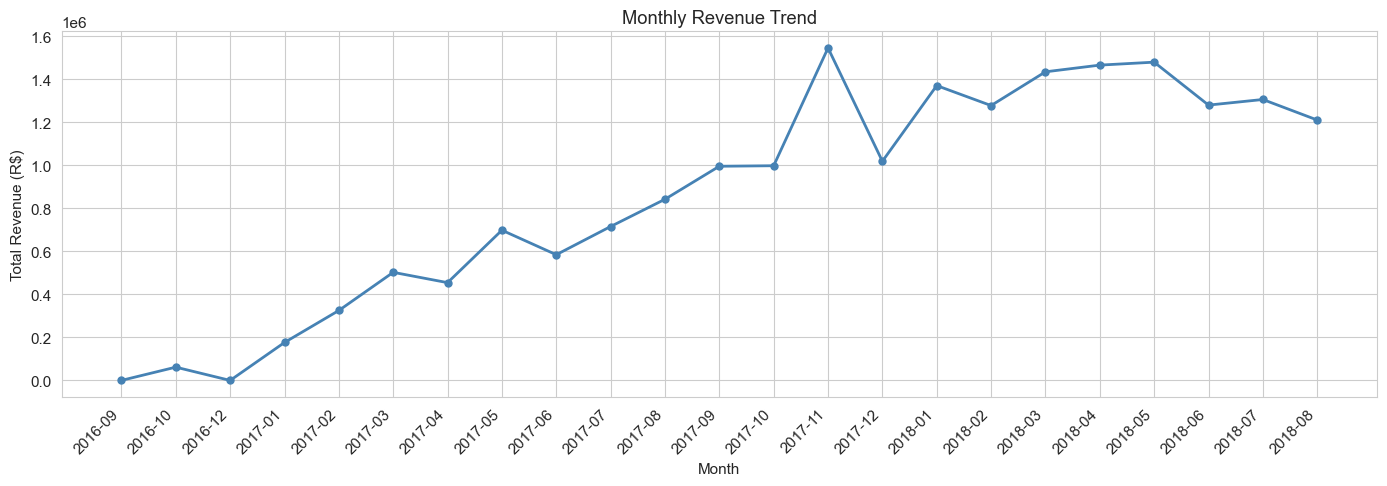

Best month: 2017-11  →  R$1,546,419


In [8]:
# Group all orders by year and month, then sum the revenue for each month
monthly = (
    df.groupby(["year", "month"])["revenue"]
    .sum()
    .reset_index()
    .sort_values(["year", "month"])
)

# Create a readable label for the X axis like "2017-01", "2017-02"
# zfill(2) adds a leading zero so 1 becomes 01, 9 becomes 09
monthly["period"] = (
    monthly["year"].astype(str) + "-" +
    monthly["month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(14, 5))
plt.plot(
    monthly["period"], monthly["revenue"],
    marker="o", color="steelblue", linewidth=2, markersize=5
)
plt.xticks(rotation=45, ha="right")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue (R$)")
plt.tight_layout()
plt.savefig("eda_monthly_trend.png", dpi=150)
plt.show()

# Find the single best month
best = monthly.loc[monthly["revenue"].idxmax()]
print(f"Best month: {best['period']}  →  R${best['revenue']:,.0f}")

**Insight from this chart:**
Look for seasonality — are there months that are consistently higher?
A peak in November-December is common in e-commerce due to holiday shopping.
Mention this trend when interviewers ask about your analysis.

## Step 5 — Top 10 Product Categories by Revenue

Which types of products are generating the most money?
This helps the business understand where to focus inventory and marketing.
We use a horizontal bar chart because category names are long text — easier to read this way.

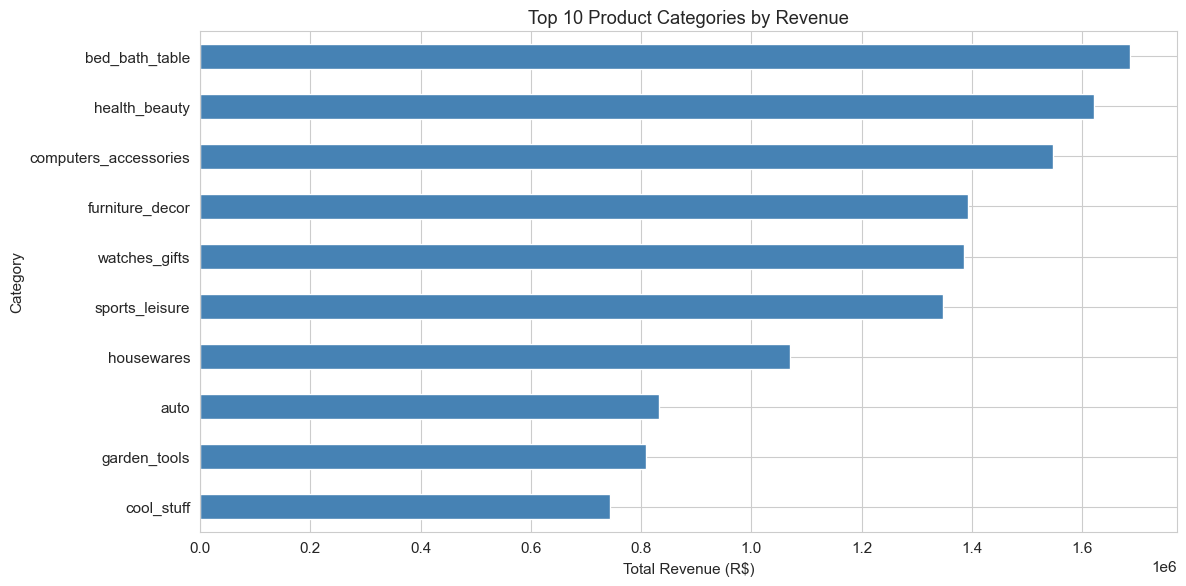

Top 3 categories:
  bed_bath_table: R$1,687,696
  health_beauty: R$1,620,719
  computers_accessories: R$1,547,996


In [11]:
# Group by category, sum the revenue, and take the top 10
top_categories = (
    df[df["category"] != "Unknown"]   # skip rows with no category name
    .groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=True)      # ascending=True so the biggest bar is at the top
    .tail(10)
)

plt.figure(figsize=(12, 6))
top_categories.plot(kind="barh", color="steelblue", edgecolor="white")
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Total Revenue (R$)")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("eda_top_categories.png", dpi=150)
plt.show()

print("Top 3 categories:")
for cat, rev in top_categories.iloc[::-1].head(3).items():
    print(f"  {cat}: R${rev:,.0f}")

**Insight from this chart:**
The top category by revenue is a strong candidate for targeted promotions.
If a high-revenue category also has a low review score, that is a red flag for the business.
We will cross-check review scores in a later step.

## Step 6 — Delivery Time Distribution

How long does delivery typically take?
A histogram with a smooth curve (KDE = Kernel Density Estimate) shows
both the raw counts and the overall shape of the distribution at the same time.

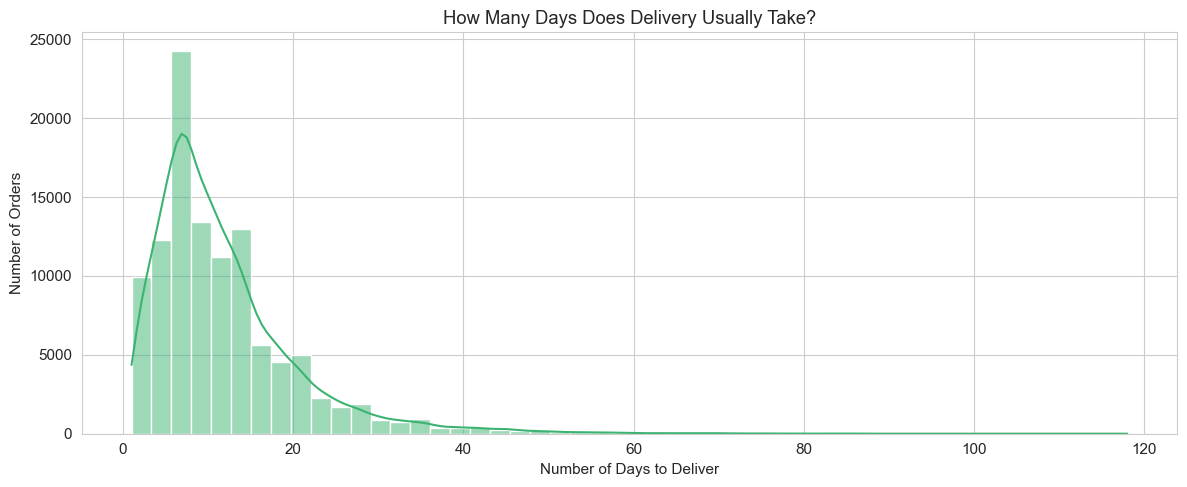

Average delivery time   : 11.9 days
Median delivery time    : 10 days
Fastest delivery        : 1.0 day(s)
Slowest delivery        : 118.0 days
Half of all orders arrive within 10 days


In [12]:
plt.figure(figsize=(12, 5))

# kde=True draws a smooth curved line over the bars
# This shows the overall shape of the distribution more clearly
sns.histplot(
    df["delivery_days"],
    bins=50,
    color="mediumseagreen",
    kde=True,
    edgecolor="white"
)
plt.title("How Many Days Does Delivery Usually Take?")
plt.xlabel("Number of Days to Deliver")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig("eda_delivery_days.png", dpi=150)
plt.show()

print(f"Average delivery time   : {df['delivery_days'].mean():.1f} days")
print(f"Median delivery time    : {df['delivery_days'].median():.0f} days")
print(f"Fastest delivery        : {df['delivery_days'].min()} day(s)")
print(f"Slowest delivery        : {df['delivery_days'].max()} days")
print(f"Half of all orders arrive within {df['delivery_days'].median():.0f} days")

**Insight from this chart:**
Most deliveries happen within a predictable window.
A long right tail (the curve stretching far right) means some deliveries
take unusually long — these are likely the ones getting bad reviews.

## Step 7 — Late vs On Time Deliveries

is_late = 1 means the order arrived after the estimated delivery date.
is_late = 0 means it arrived on time or early.

A pie chart works well here because we are comparing just two categories.

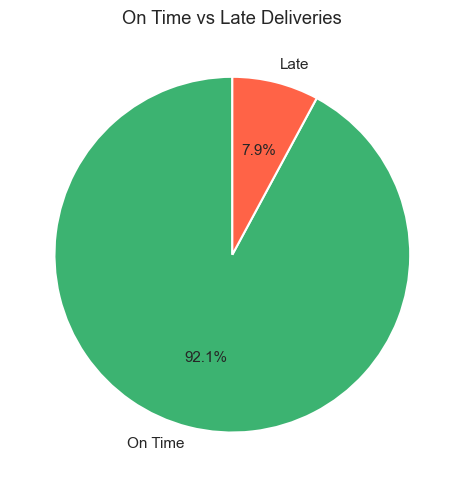

7.9% of all orders were delivered late


In [13]:
# Count how many orders were late vs on time
late_counts = df["is_late"].value_counts().sort_index()
labels      = ["On Time", "Late"]
colors      = ["mediumseagreen", "tomato"]

plt.figure(figsize=(7, 5))
plt.pie(
    late_counts,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",   # show the percentage inside each slice
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
plt.title("On Time vs Late Deliveries")
plt.tight_layout()
plt.savefig("eda_late_pie.png", dpi=150)
plt.show()

late_pct = df["is_late"].mean() * 100
print(f"{late_pct:.1f}% of all orders were delivered late")

**Insight from this chart:**
Even a small late percentage matters in e-commerce.
If X% of 100,000 orders are late, that is thousands of unhappy customers.
The next step checks whether late deliveries actually hurt review scores.

## Step 8 — Does Late Delivery Hurt Customer Reviews?

This is one of the most important business insights in this analysis.
We compare the average review score for on-time orders vs late orders.
If late orders consistently get lower scores, the business needs to fix its delivery process.

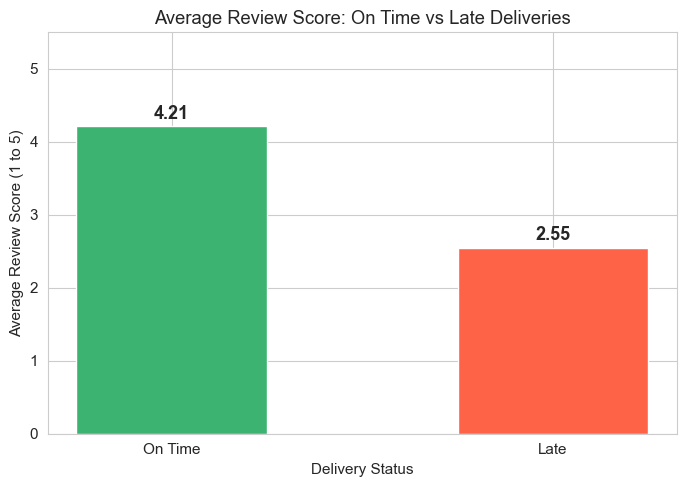

On time average review : 4.21
Late average review    : 2.55
Difference             : 1.66 stars


In [14]:
# Calculate the average review score for each delivery status
review_by_lateness = (
    df.groupby("is_late")["review_score"]
    .mean()
    .round(2)
    .reset_index()
)
review_by_lateness["label"] = ["On Time", "Late"]

# Bar chart comparing the two groups
plt.figure(figsize=(7, 5))
bars = plt.bar(
    review_by_lateness["label"],
    review_by_lateness["review_score"],
    color=["mediumseagreen", "tomato"],
    edgecolor="white",
    width=0.5
)
plt.title("Average Review Score: On Time vs Late Deliveries")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score (1 to 5)")
plt.ylim(0, 5.5)

# Show the actual number on top of each bar
for bar, row in zip(bars, review_by_lateness.itertuples()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        str(row.review_score),
        ha="center", fontweight="bold", fontsize=13
    )

plt.tight_layout()
plt.savefig("eda_reviews_vs_late.png", dpi=150)
plt.show()

on_time_score = review_by_lateness.loc[0, "review_score"]
late_score    = review_by_lateness.loc[1, "review_score"]
print(f"On time average review : {on_time_score}")
print(f"Late average review    : {late_score}")
print(f"Difference             : {on_time_score - late_score:.2f} stars")

**Insight from this chart:**
Late deliveries get a noticeably lower review score.
This is a clear signal: improving delivery speed directly improves customer satisfaction.
This kind of finding is exactly what businesses pay data analysts to discover.

## Step 9 — Which Day of the Week Has the Most Orders?

Do customers order more on weekdays or weekends?
Understanding ordering patterns helps the business plan staffing and warehouse operations.

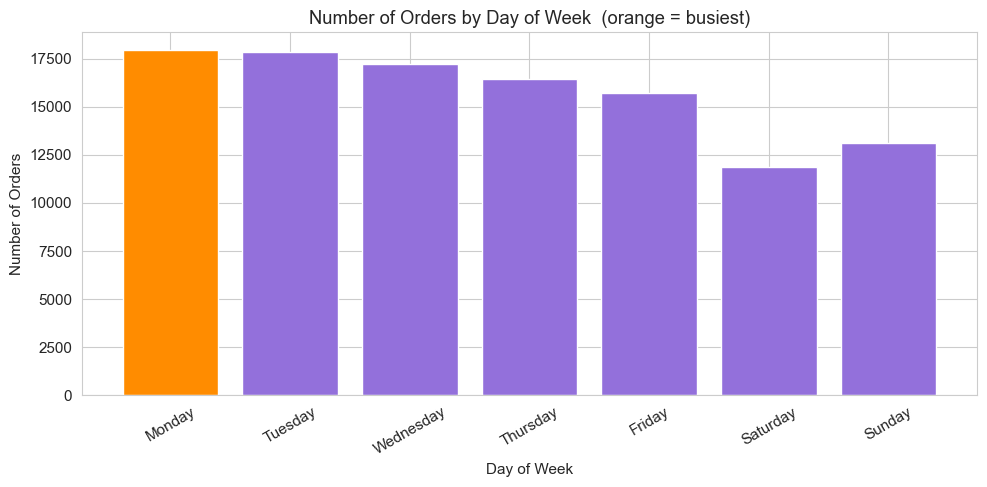

Busiest day  : Monday  (17,964 orders)
Quietest day : Saturday  (11,878 orders)


In [15]:
# Force Monday to Sunday order instead of alphabetical
day_order  = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

day_counts = (
    df.groupby("day_of_week")["order_id"]
    .count()
    .reindex(day_order)  # reindex forces our custom order
)

# Find the busiest day so we can highlight it
busiest_day = day_counts.idxmax()
bar_colors  = ["darkorange" if d == busiest_day else "mediumpurple" for d in day_order]

plt.figure(figsize=(10, 5))
plt.bar(day_counts.index, day_counts.values, color=bar_colors, edgecolor="white")
plt.title("Number of Orders by Day of Week  (orange = busiest)")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("eda_day_of_week.png", dpi=150)
plt.show()

print(f"Busiest day  : {day_counts.idxmax()}  ({day_counts.max():,} orders)")
print(f"Quietest day : {day_counts.idxmin()}  ({day_counts.min():,} orders)")

## Step 10 — Top 10 States by Revenue

Brazil has 27 states. Which ones are driving the most business?
This helps the business decide where to focus marketing and improve logistics.

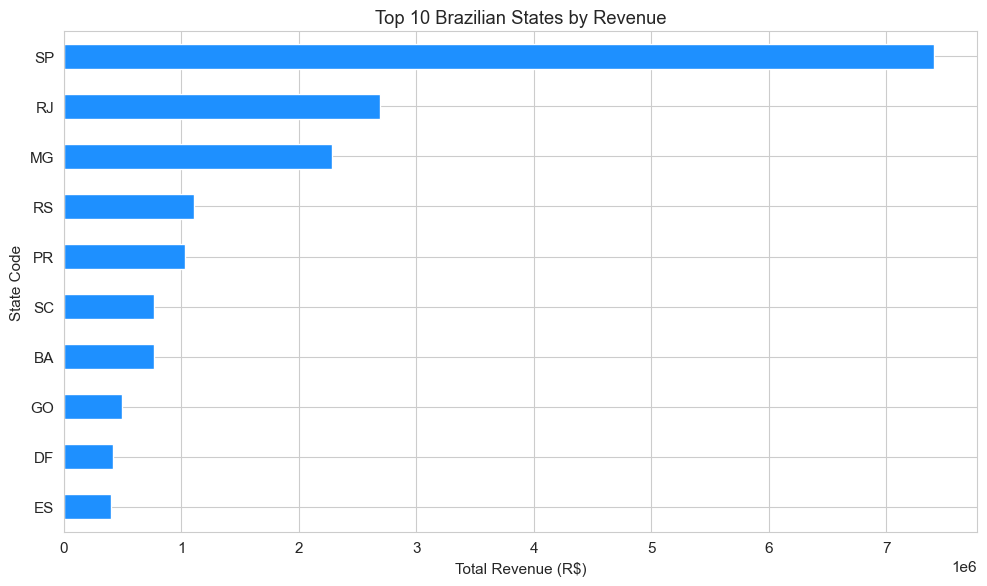

Top 3 states:
  SP: R$7,400,283
  RJ: R$2,686,383
  MG: R$2,280,093


In [16]:
top_states = (
    df.groupby("customer_state")["revenue"]
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

plt.figure(figsize=(10, 6))
top_states.plot(kind="barh", color="dodgerblue", edgecolor="white")
plt.title("Top 10 Brazilian States by Revenue")
plt.xlabel("Total Revenue (R$)")
plt.ylabel("State Code")
plt.tight_layout()
plt.savefig("eda_top_states.png", dpi=150)
plt.show()

print("Top 3 states:")
for state, rev in top_states.iloc[::-1].head(3).items():
    print(f"  {state}: R${rev:,.0f}")

## Step 11 — Revenue by Quarter

How does revenue compare across Q1, Q2, Q3, and Q4 each year?
This tells us if there is seasonal growth in the business.

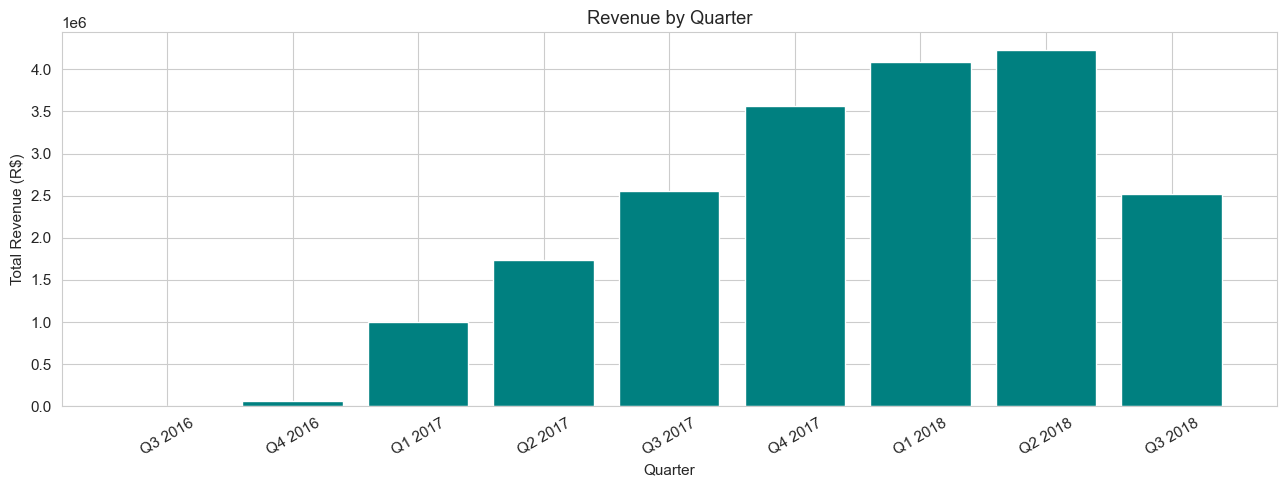

In [17]:
quarterly = (
    df.groupby(["year", "quarter"])["revenue"]
    .sum()
    .reset_index()
)

# Create a readable label like "Q1 2017", "Q2 2017"
quarterly["label"] = "Q" + quarterly["quarter"].astype(str) + " " + quarterly["year"].astype(str)

plt.figure(figsize=(13, 5))
plt.bar(quarterly["label"], quarterly["revenue"], color="teal", edgecolor="white")
plt.title("Revenue by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Total Revenue (R$)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("eda_quarterly.png", dpi=150)
plt.show()

## Summary — Key Findings

This is the most important cell in the entire notebook.
Below are the key insights we discovered through EDA.

In [18]:
# Pull numbers from the actual data so the summary is always accurate
avg_rev      = df["revenue"].mean()
med_rev      = df["revenue"].median()
late_pct     = df["is_late"].mean() * 100
avg_del      = df["delivery_days"].mean()
on_time_rv   = df[df["is_late"]==0]["review_score"].mean()
late_rv      = df[df["is_late"]==1]["review_score"].mean()
busiest      = df.groupby("day_of_week")["order_id"].count().idxmax()
top_cat      = (df[df["category"]!="Unknown"]
                .groupby("category")["revenue"].sum().idxmax())

print("=" * 55)
print("KEY FINDINGS FROM EDA")
print("=" * 55)
print(f"""
Dataset   : {df.shape[0]:,} delivered orders
Period    : {df['year'].min()} to {df['year'].max()}

1. REVENUE
   Average order value : R${avg_rev:,.0f}
   Median order value  : R${med_rev:,.0f}
   → Median is lower because a few large orders pull the average up

2. DELIVERY
   {late_pct:.1f}% of all orders were delivered late
   Average delivery time: {avg_del:.1f} days

3. CUSTOMER SATISFACTION
   On-time deliveries  : {on_time_rv:.2f} average review score
   Late deliveries     : {late_rv:.2f} average review score
   → Late delivery directly hurts customer satisfaction

4. ORDERING PATTERNS
   Busiest ordering day: {busiest}
   Top revenue category: {top_cat}
""")

KEY FINDINGS FROM EDA

Dataset   : 110,123 delivered orders
Period    : 2016 to 2018

1. REVENUE
   Average order value : R$179
   Median order value  : R$114
   → Median is lower because a few large orders pull the average up

2. DELIVERY
   7.9% of all orders were delivered late
   Average delivery time: 11.9 days

3. CUSTOMER SATISFACTION
   On-time deliveries  : 4.21 average review score
   Late deliveries     : 2.55 average review score
   → Late delivery directly hurts customer satisfaction

4. ORDERING PATTERNS
   Busiest ordering day: Monday
   Top revenue category: bed_bath_table

